In this notebook Seamese network model for handwriting author verification trained. As backbpn ResNet50 used with freezed parameters.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install torchvision

In [4]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

from torch.utils.data import Dataset
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


In [6]:
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/patches_output.zip', 'r') as z:
    z.extractall('/content/data')

DATA_ROOT = '/content/data/patches_output'
print(f"Authors: {len(os.listdir(DATA_ROOT))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Authors: 657


Let's create class SiameseNetworkDataset for our data.
The dataset takes random pairs and create either positive (one author) or negative pair. The labels are created at random, the balance shall be ~50/50.
The pairs are created 'on the fly'.

In [7]:
class SiameseNetworkDataset(Dataset):
    def __init__(self, root, transform=None, train=True, size=100,
                 min_height=100, max_height=500, authors_list=None):
        self.transform = transform
        self.train = train
        self.size = size
        self.min_height = min_height
        self.max_height = max_height

        self.authors_data_positive = {}
        self.authors_data_all = {}

        # Если передан список авторов (для разделения train/val)
        if authors_list is not None:
            folders_to_scan = [f for f in os.listdir(root) if f in authors_list]
        else:
            folders_to_scan = os.listdir(root)

        for folder in folders_to_scan:
            author_path = os.path.join(root, folder)
            if not os.path.isdir(author_path):
                continue

            valid_images = []
            for file in os.listdir(author_path):
                if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue

                img_path = os.path.join(author_path, file)
                try:
                    with Image.open(img_path) as img:
                        height = img.size[1]
                    if self.min_height <= height <= self.max_height:
                        valid_images.append(file)
                except Exception:
                    continue

            if not valid_images:
                continue

            self.authors_data_all[author_path] = valid_images
            if len(valid_images) >= 2:
                self.authors_data_positive[author_path] = valid_images

        self.authors_paths_positive = list(self.authors_data_positive.keys())
        self.authors_paths_all = list(self.authors_data_all.keys())

        print(f"  Positive authors (>=2 images): {len(self.authors_paths_positive)}")
        print(f"  Total authors: {len(self.authors_paths_all)}")

        if len(self.authors_paths_positive) == 0:
            raise ValueError("No authors with at least 2 valid images!")

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        #creating labelfrom random.
        label = random.randint(0, 1)

        if label == 1:
            # Positive pair: same author
            author_path = random.choice(self.authors_paths_positive)
            images = self.authors_data_positive[author_path]
            img1_name, img2_name = random.sample(images, 2)
            img_path1 = os.path.join(author_path, img1_name)
            img_path2 = os.path.join(author_path, img2_name)

        else:
            #create negative pair
            if len(self.authors_paths_all) < 2:
                author_path = random.choice(self.authors_paths_positive)
                images = self.authors_data_positive[author_path]
                img1_name, img2_name = random.sample(images, 2)
                img_path1 = os.path.join(author_path, img1_name)
                img_path2 = os.path.join(author_path, img2_name)
                label = 1
            else:
                author1_path, author2_path = random.sample(self.authors_paths_all, 2)
                images1 = self.authors_data_all[author1_path]
                images2 = self.authors_data_all[author2_path]

                img1_name = random.choice(images1)
                img2_name = random.choice(images2)

                img_path1 = os.path.join(author1_path, img1_name)
                img_path2 = os.path.join(author2_path, img2_name)


        img1 = Image.open(img_path1).convert('L')
        img2 = Image.open(img_path2).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

In [8]:
#splitting authors into train and val
import random
all_authors = [f for f in os.listdir(DATA_ROOT)
               if os.path.isdir(os.path.join(DATA_ROOT, f))]
random.shuffle(all_authors)

split_idx = int(len(all_authors) * 0.8)
train_authors = all_authors[:split_idx]
val_authors = all_authors[split_idx:]

print(f"Train authors: {len(train_authors)}, Val authors: {len(val_authors)}")

Train authors: 525, Val authors: 132


In [9]:
class ResizeTextPatch:
    """
    Adaptive resize of wide patches.
    Preserve propotions target_h × target_w.
    """
    def __init__(self, target_h=192, target_w=512):
        self.target_h = target_h
        self.target_w = target_w

    def __call__(self, img):
        w, h = img.size  # PIL: width, height

        # Calculating scale
        scale_h = self.target_h / h
        scale_w = self.target_w / w
        scale = min(scale_h, scale_w)

        new_w = int(w * scale)
        new_h = int(h * scale)

        # Resizing with interpolation
        img = TF.resize(img, [new_h, new_w], interpolation=TF.InterpolationMode.BICUBIC)

        # Creating black square
        new_img = Image.new('L', (self.target_w, self.target_h), 0)

        # Centerring the image
        paste_x = (self.target_w - new_w) // 2
        paste_y = (self.target_h - new_h) // 2
        new_img.paste(img, (paste_x, paste_y))

        return new_img

In [10]:
train_transform = T.Compose([

    ResizeTextPatch(target_h=384, target_w=1014),
    T.RandomRotation(3),
    T.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),
    T.ToTensor(),
    T.Normalize(mean=[0.485], std=[0.229])  # ImageNet stats for 1 channel
])

val_transform = T.Compose([
    ResizeTextPatch(target_h=384, target_w=1014),
    T.ToTensor(),
    T.Normalize(mean=[0.485], std=[0.229])
])

In [11]:
train_dataset = SiameseNetworkDataset(
    root=DATA_ROOT,
    transform=train_transform,
    train=True,
    size=2500,
    min_height=100,
    max_height=500,
    authors_list=train_authors
)

val_dataset = SiameseNetworkDataset(
    root=DATA_ROOT,
    transform=val_transform,
    train=False,
    size=2000,
    min_height=100,
    max_height=500,
    authors_list=val_authors
)

  Positive authors (>=2 images): 422
  Total authors: 512
  Positive authors (>=2 images): 113
  Total authors: 132


Lbael: 1
Size img1: torch.Size([1, 384, 1014])
Size img2: torch.Size([1, 384, 1014])


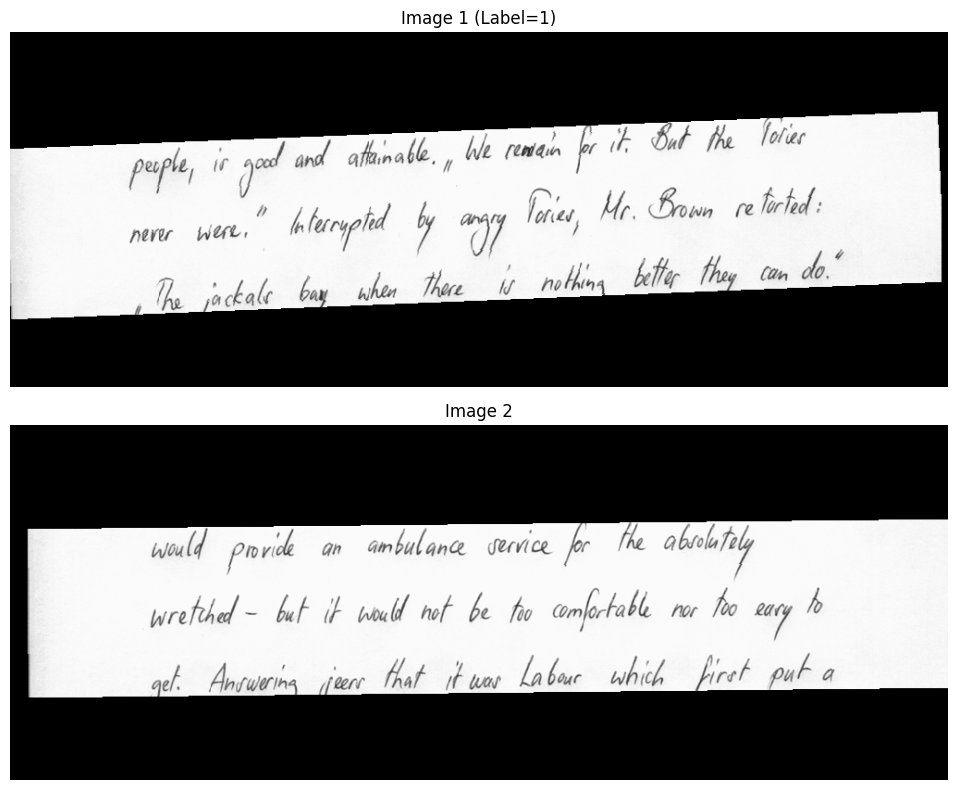

In [12]:
img1, img2, label = train_dataset[3]

print(f"Lbael: {label}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
labels=[]

for i in range(len(train_dataset)):
  labels.append(train_dataset[i][2])

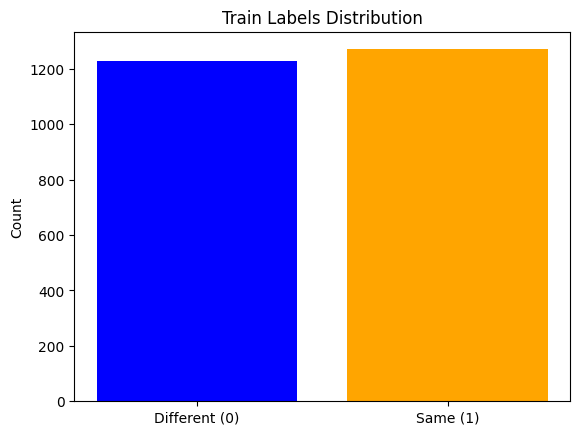

In [18]:
counts = [labels.count(0), labels.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Train Labels Distribution')
plt.show()

In [13]:
# creating DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Let's create class for our model. The class has freeze_mode parameter (aggressive or moderate), in aggressive mode we freeze all layer except for the last one, in moderate except for 2 lasts.For training we use Contrastive loss+BCE

In [14]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_size=256, freeze_mode=None):
        super(SiameseNetwork, self).__init__()

        # Upload model
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Adapt the first layer for one channel
        original_conv1 = backbone.conv1
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        backbone.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)

        # Deleting the last FC layer
        self.resnet = nn.Sequential(*list(backbone.children())[:-1])

        # Freezeing layers
        if freeze_mode == "aggressive":
            # Freezing all
            for param in self.resnet.parameters():
                param.requires_grad = False

            # Unfreze layer4
            for name, param in self.resnet.named_parameters():
                if 'layer4' in name:
                    param.requires_grad = True

            # Unfreeze conv1
            if hasattr(self.resnet[0], 'weight'):
                for param in self.resnet[0].parameters():
                    param.requires_grad = True

        elif freeze_mode == "moderate":
            # Freezing all
            for param in self.resnet.parameters():
                param.requires_grad = False

            # Unfreze layer3 and layer4
            for name, param in self.resnet.named_parameters():
                if 'layer3' in name or 'layer4' in name:
                    param.requires_grad = True

            # Unfreeze conv1
            if hasattr(self.resnet[0], 'weight'):
                for param in self.resnet[0].parameters():
                    param.requires_grad = True

        else:
            pass

        # Embedding head
        self.embedding = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, embedding_size)
        )

        # Classifier head
        self.classifier = nn.Linear(embedding_size, 1)

        self.embedding_size = embedding_size

        # Statistics
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total parameters: {total:,}")
        print(f"Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

    #forward pass for one image
    def forward_one(self, x):
        x = self.resnet(x)
        x = x.view(x.size(0), -1)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)

    #forward pass for 2 images, classification
    def forward(self, x1, x2):
        out1 = self.forward_one(x1)
        out2 = self.forward_one(x2)

        # L1 distance
        distance = torch.abs(out1 - out2)

        # Logits for BCEWithLogitsLoss
        logits = self.classifier(distance).squeeze(1)

        return logits, out1, out2

In [15]:
class ContrastiveLoss(nn.Module):
    """Contrastive loss"""

    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Eucledian distance
        distance = F.pairwise_distance(output1, output2)

        loss = label * torch.pow(distance, 2) / 2
        loss += (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2) / 2

        return loss.mean()

In [18]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.001,
    device=None,
    save_path='best_model.pth'
):
    """Training Siamese network with fixed contrastive loss"""

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Move model to device
    model = model.to(device)

    # Optimizer and scheduler
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )

    # Loss functions
    contrastive_loss = ContrastiveLoss(margin=1.0)
    bce_loss = nn.BCEWithLogitsLoss()

    # History tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_roc_auc': [], 'val_roc_auc': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        # training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_labels = []
        train_preds = []


        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for img1, img2, labels in pbar:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            logits, emb1, emb2 = model(img1, img2)

            loss_contrastive = contrastive_loss(emb1, emb2, labels)
            loss_bce = bce_loss(logits, labels)
            loss = loss_contrastive + loss_bce

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            probs = torch.sigmoid(logits)
            predicted = (probs > 0.5).float()
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

            train_labels.extend(labels.cpu().numpy())
            train_preds.extend(probs.detach().cpu().numpy())  # use probs for ROC-AUC

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{train_correct/train_total:.3f}'
                }
            )

        train_acc = train_correct / train_total
        train_loss_avg = train_loss / len(train_loader)
        train_roc_auc = roc_auc_score(train_labels, train_preds)


        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_labels = []
        val_preds = []


        with torch.no_grad():
            for img1, img2, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                img1 = img1.to(device)
                img2 = img2.to(device)
                labels = labels.float().to(device)

                logits, emb1, emb2 = model(img1, img2)

                loss_contrastive = contrastive_loss(emb1, emb2, labels)
                loss_bce = bce_loss(logits, labels)
                loss = loss_contrastive + 0.05 * loss_bce

                val_loss += loss.item()

                probs = torch.sigmoid(logits)
                predicted = (probs > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                val_labels.extend(labels.cpu().numpy())
                val_preds.extend(probs.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss_avg = val_loss / len(val_loader)
        val_roc_auc = roc_auc_score(val_labels, val_preds)

        # Update scheduler
        scheduler.step(val_loss_avg)

        # Save history
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_roc_auc'].append(train_roc_auc)
        history['val_roc_auc'].append(val_roc_auc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Print results
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc:.4f}, ROC-AUC: {train_roc_auc:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, Val Acc:   {val_acc:.4f}, ROC-AUC: {val_roc_auc:.4f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best model by ROC-AUC
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_roc_auc': val_roc_auc
            }, save_path)
            print(f"Model saved. Val Acc: {val_acc:.4f}, Val ROC-AUC: {val_roc_auc:.4f}")

    return history

In [19]:
model = SiameseNetwork(embedding_size=256, freeze_mode='aggressive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_scratch.pth')

print(f"\nBest Val ROC-AUC: {max(history['val_roc_auc'])*100:.2f}%")

Total parameters: 25,862,593
Trainable parameters: 2,363,969 (9.1%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [02:47<00:00,  1.49it/s]



Epoch 1/30
  Train Loss: 0.8210, Train Acc: 0.5152, ROC-AUC: 0.4976
  Val Loss:   0.2815, Val Acc:   0.4955, ROC-AUC: 0.8511
  LR: 0.001000
Model saved. Val Acc: 0.4955, Val ROC-AUC: 0.8511


Epoch 2/30 [Val]: 100%|██████████| 250/250 [02:48<00:00,  1.48it/s]



Epoch 2/30
  Train Loss: 0.8226, Train Acc: 0.5144, ROC-AUC: 0.4901
  Val Loss:   0.2767, Val Acc:   0.5090, ROC-AUC: 0.8568
  LR: 0.001000
Model saved. Val Acc: 0.5090, Val ROC-AUC: 0.8568


...


Epoch 3/30
  Train Loss: 0.8223, Train Acc: 0.4856, ROC-AUC: 0.4873
  Val Loss:   0.2812, Val Acc:   0.4975, ROC-AUC: 0.7865
  LR: 0.001000


Epoch 4/30 [Val]: 100%|██████████| 250/250 [02:47<00:00,  1.49it/s]



Epoch 4/30
  Train Loss: 0.8231, Train Acc: 0.4808, ROC-AUC: 0.4767
  Val Loss:   0.2832, Val Acc:   0.4915, ROC-AUC: 0.8559
  LR: 0.001000


Epoch 5/30 [Train]:  10%|▉         | 31/313 [00:51<07:47,  1.66s/it, loss=0.8078, acc=0.492]


KeyboardInterrupt: 

In [20]:
model = SiameseNetwork(embedding_size=256, freeze_mode='moderate')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_scratch.pth'
)

print(f"\nBest Val ROC-AUC: {max(history['val_roc_auc'])*100:.2f}%")

Total parameters: 25,862,593
Trainable parameters: 2,363,969 (9.1%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [02:47<00:00,  1.49it/s]



Epoch 1/30
  Train Loss: 0.8227, Train Acc: 0.5048, ROC-AUC: 0.4874
  Val Loss:   0.2772, Val Acc:   0.4930, ROC-AUC: 0.1789
  LR: 0.001000
Model saved. Val Acc: 0.4930, Val ROC-AUC: 0.1789


Epoch 2/30 [Val]: 100%|██████████| 250/250 [02:47<00:00,  1.50it/s]



Epoch 2/30
  Train Loss: 0.8224, Train Acc: 0.4888, ROC-AUC: 0.4821
  Val Loss:   0.2815, Val Acc:   0.5065, ROC-AUC: 0.7929
  LR: 0.001000
Model saved. Val Acc: 0.5065, Val ROC-AUC: 0.7929


Epoch 3/30 [Val]: 100%|██████████| 250/250 [02:46<00:00,  1.50it/s]



Epoch 3/30
  Train Loss: 0.8209, Train Acc: 0.4940, ROC-AUC: 0.4860
  Val Loss:   0.2752, Val Acc:   0.4910, ROC-AUC: 0.2773
  LR: 0.001000


Epoch 4/30 [Train]:  33%|███▎      | 102/313 [02:46<05:44,  1.63s/it, loss=0.8215, acc=0.485]


KeyboardInterrupt: 

<>:57: SyntaxWarning: invalid escape sequence '\A'
<>:57: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1386/2694413233.py:57: SyntaxWarning: invalid escape sequence '\A'
  print("\Aggressive freeze")


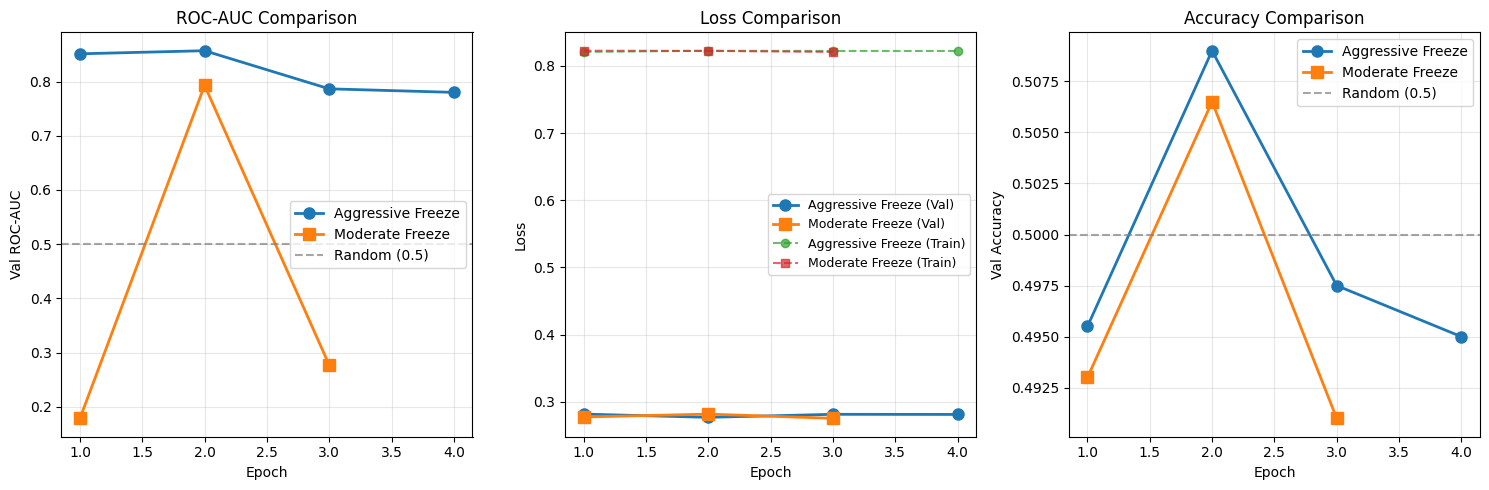

\Aggressive freeze
  Best Val ROC-AUC: 0.8568 (Epoch 2)
  Best Val Accuracy: 0.5090
  Final Val ROC-AUC: 0.7800

Moderate freeze
Best Val ROC-AUC: 0.7929 (Epoch 2)
Best Val Accuracy: 0.5065
Final Val ROC-AUC: 0.2773


In [22]:
epochs_agg = [1, 2, 3, 4]
train_loss_agg = [0.8210, 0.8226, 0.8223, 0.8223]  # approximate from logs
train_acc_agg = [0.5152, 0.5144, 0.4856, 0.4810]
train_roc_agg = [0.4976, 0.4901, 0.4873, 0.4870]  # approximated
val_loss_agg = [0.2815, 0.2767, 0.2812, 0.2810]  # approximated
val_acc_agg = [0.4955, 0.5090, 0.4975, 0.4950]  # approximated
val_roc_agg = [0.8511, 0.8568, 0.7865, 0.7800]  # approximated

# Model 2: Moderate freeze
epochs_mod = [1, 2, 3]
train_loss_mod = [0.8227, 0.8224, 0.8209]
train_acc_mod = [0.5048, 0.4888, 0.4940]
train_roc_mod = [0.4874, 0.4821, 0.4860]
val_loss_mod = [0.2772, 0.2815, 0.2752]
val_acc_mod = [0.4930, 0.5065, 0.4910]
val_roc_mod = [0.1789, 0.7929, 0.2773]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. ROC-AUC comparison
axes[0].plot(epochs_agg, val_roc_agg, 'o-', label='Aggressive Freeze', linewidth=2, markersize=8)
axes[0].plot(epochs_mod, val_roc_mod, 's-', label='Moderate Freeze', linewidth=2, markersize=8)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random (0.5)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val ROC-AUC')
axes[0].set_title('ROC-AUC Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Loss comparison
axes[1].plot(epochs_agg, val_loss_agg, 'o-', label='Aggressive Freeze (Val)', linewidth=2, markersize=8)
axes[1].plot(epochs_mod, val_loss_mod, 's-', label='Moderate Freeze (Val)', linewidth=2, markersize=8)
axes[1].plot(epochs_agg, train_loss_agg, 'o--', label='Aggressive Freeze (Train)', linewidth=1.5, markersize=6, alpha=0.7)
axes[1].plot(epochs_mod, train_loss_mod, 's--', label='Moderate Freeze (Train)', linewidth=1.5, markersize=6, alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Comparison')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# 3. Accuracy comparison
axes[2].plot(epochs_agg, val_acc_agg, 'o-', label='Aggressive Freeze', linewidth=2, markersize=8)
axes[2].plot(epochs_mod, val_acc_mod, 's-', label='Moderate Freeze', linewidth=2, markersize=8)
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random (0.5)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Val Accuracy')
axes[2].set_title('Accuracy Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


print("\Aggressive freeze")
print(f"  Best Val ROC-AUC: {max(val_roc_agg):.4f} (Epoch {val_roc_agg.index(max(val_roc_agg)) + 1})")
print(f"  Best Val Accuracy: {max(val_acc_agg):.4f}")
print(f"  Final Val ROC-AUC: {val_roc_agg[-1]:.4f}")

print("\nModerate freeze")
print(f"Best Val ROC-AUC: {max(val_roc_mod):.4f} (Epoch {val_roc_mod.index(max(val_roc_mod)) + 1})")
print(f"Best Val Accuracy: {max(val_acc_mod):.4f}")
print(f"Final Val ROC-AUC: {val_roc_mod[-1]:.4f}")